In [1]:
install.packages(c("palmerpenguins", "dplyr", "ggplot2", "moments",
                    "car", "effsize", "tidyr"))

library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(moments)
library(car)
library(effsize)
library(tidyr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’



Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




In [2]:
data("penguins")
penguins_clean <- penguins %>% drop_na(body_mass_g, flipper_length_mm, sex, species)

cat("Dataset dimensions after cleaning:", dim(penguins_clean), "\n")
str(penguins_clean)
summary(penguins_clean)

Dataset dimensions after cleaning: 333 8 
tibble [333 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:333] 39.1 39.5 40.3 36.7 39.3 38.9 39.2 41.1 38.6 34.6 ...
 $ bill_depth_mm    : num [1:333] 18.7 17.4 18 19.3 20.6 17.8 19.6 17.6 21.2 21.1 ...
 $ flipper_length_mm: int [1:333] 181 186 195 193 190 181 195 182 191 198 ...
 $ body_mass_g      : int [1:333] 3750 3800 3250 3450 3650 3625 4675 3200 3800 4400 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 1 2 1 2 1 2 2 ...
 $ year             : int [1:333] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :146   Biscoe   :163   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :123   1st Qu.:39.50   1st Qu.:15.60  
 Gentoo   :119   Torgersen: 47   Median :44.50   Median :17.30  
                                 Mean   :43.99   Mean   :17.16  
                                 3rd Qu.:48.60   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172       Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190       1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197       Median :4050                Median :2008  
 Mean   :201       Mean   :4207                Mean   :2008  
 3rd Qu.:213       3rd Qu.:4775                3rd Qu.:2009  
 Max.   :231       Max.   :6300                Max.   :2009  

In [3]:
overall_stats <- penguins_clean %>%
  summarise(
    Mean = mean(body_mass_g), Median = median(body_mass_g),
    Min = min(body_mass_g), Max = max(body_mass_g),
    Variance = var(body_mass_g), SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25), Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g), Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )
print(overall_stats)

species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    n = n(), Mean = mean(body_mass_g), Median = median(body_mass_g),
    SD = sd(body_mass_g), Min = min(body_mass_g), Max = max(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25), Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g), Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )
print(species_stats)

# A tibble: 1 × 11
   Mean Median   Min   Max Variance    SD    Q1    Q3   IQR Skewness Kurtosis
  <dbl>  <int> <int> <int>    <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>    <dbl>
1 4207.   4050  2700  6300  648372.  805.  3550  4775  1225    0.470     2.26
# A tibble: 3 × 12
  species       n  Mean Median    SD   Min   Max    Q1    Q3   IQR Skewness
  <fct>     <int> <dbl>  <dbl> <dbl> <int> <int> <dbl> <dbl> <dbl>    <dbl>
1 Adelie      146 3706.   3700  459.  2850  4775 3362.  4000  638.   0.277 
2 Chinstrap    68 3733.   3700  384.  2700  4800 3488.  3950  462.   0.242 
3 Gentoo      119 5092.   5050  501.  3950  6300 4700   5500  800    0.0450
# ℹ 1 more variable: Kurtosis <dbl>


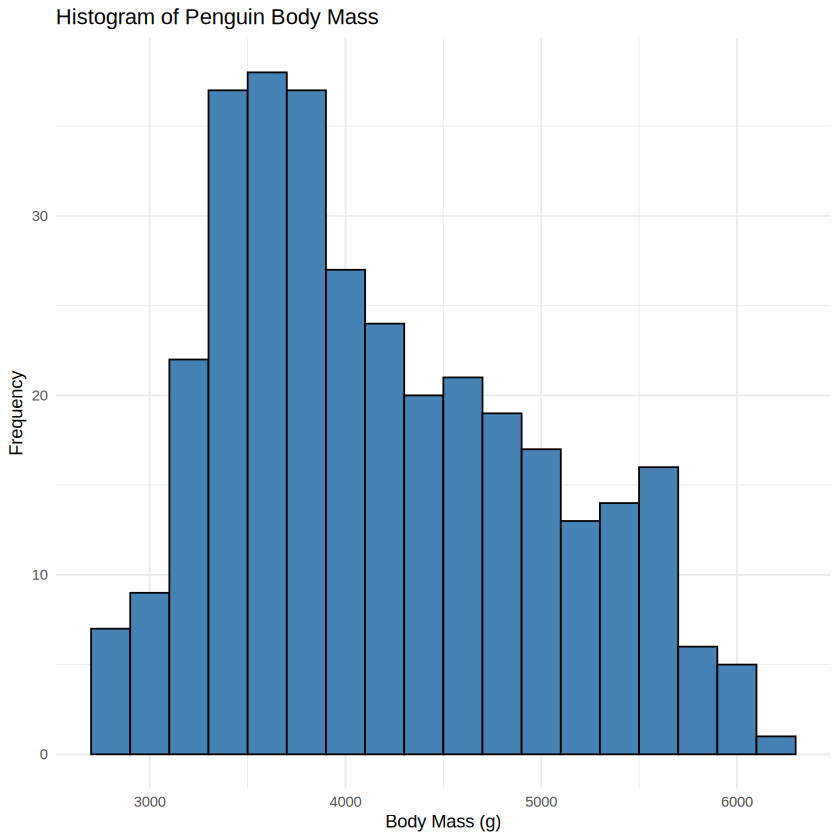

In [4]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(binwidth = 200, fill = "steelblue", color = "black") +
  labs(title = "Histogram of Penguin Body Mass", x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

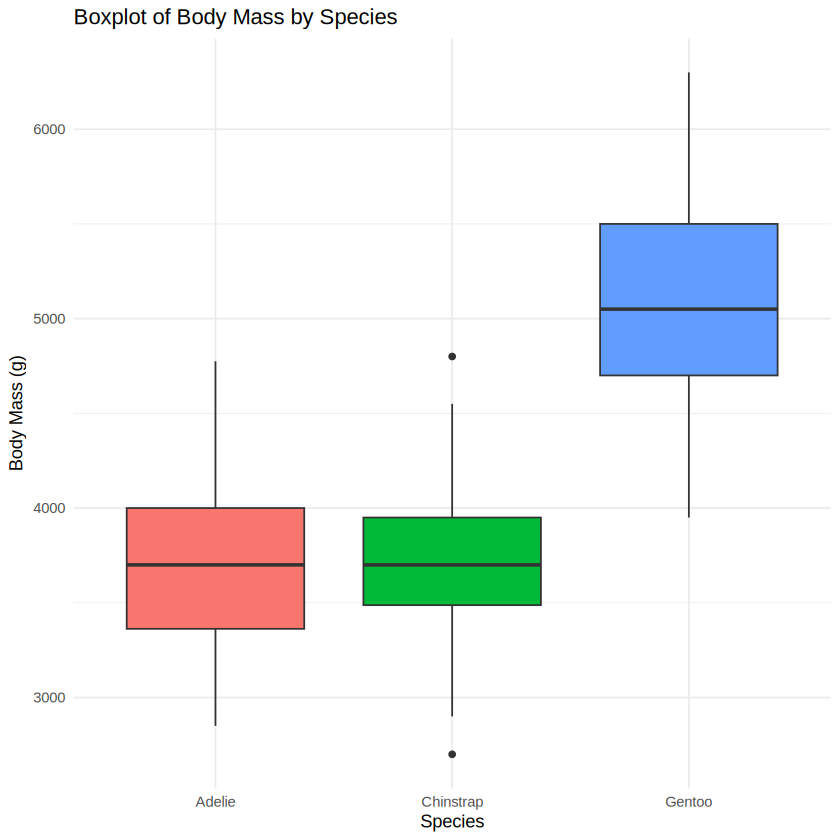

In [5]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Species", x = "Species", y = "Body Mass (g)") +
  theme_minimal() + theme(legend.position = "none")

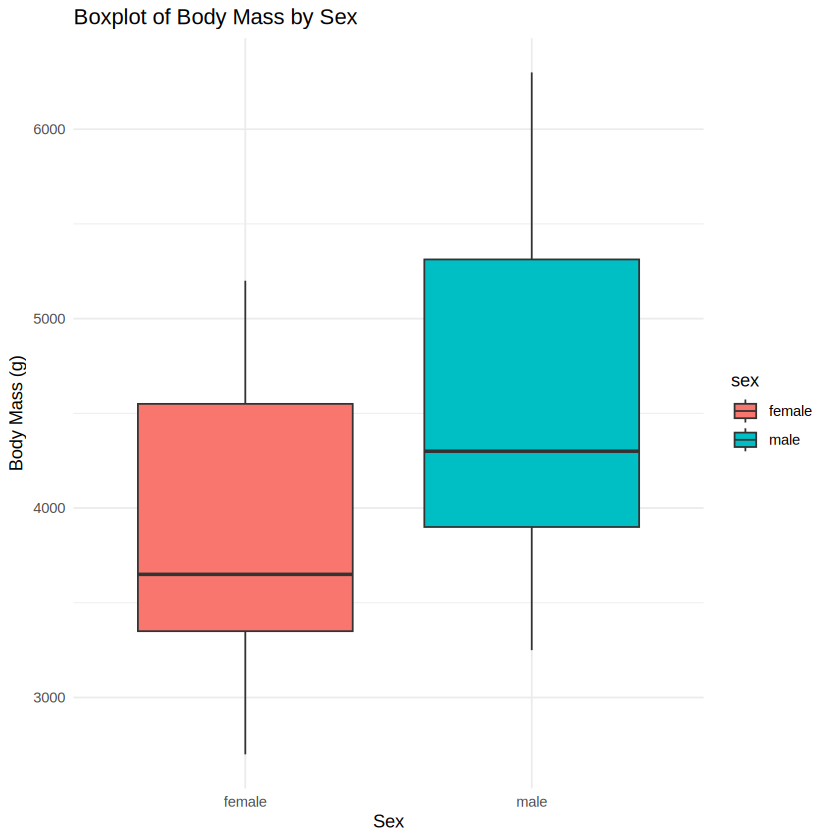

In [6]:
ggplot(penguins_clean, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Sex", x = "Sex", y = "Body Mass (g)") +
  theme_minimal()

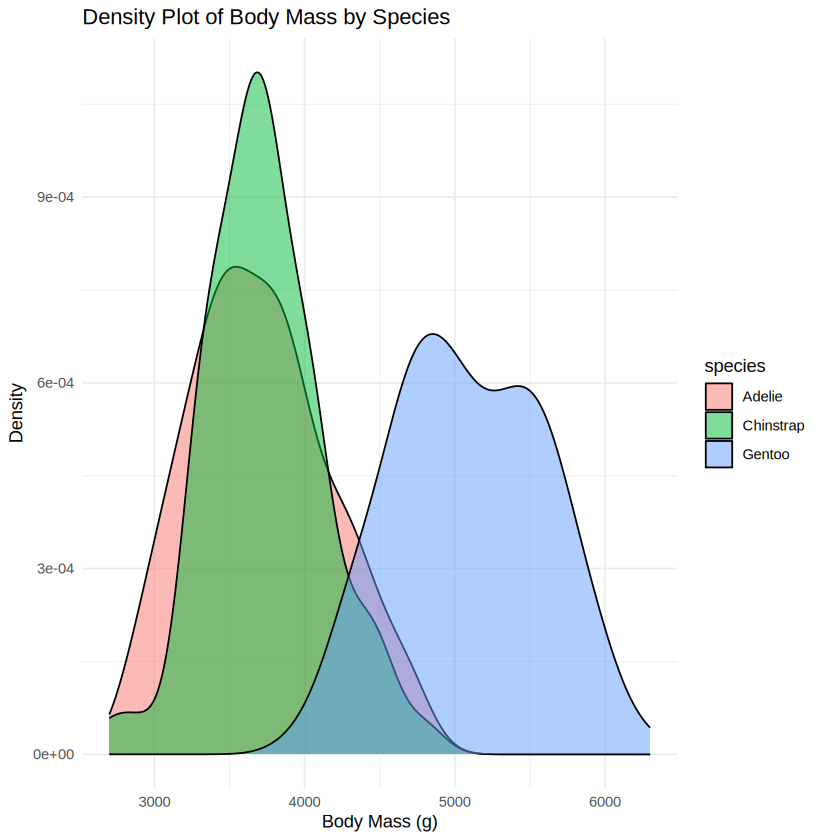

In [7]:
# Density plot
ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density Plot of Body Mass by Species", x = "Body Mass (g)", y = "Density") +
  theme_minimal()

In [8]:
male_mass   <- penguins_clean$body_mass_g[penguins_clean$sex == "male"]
female_mass <- penguins_clean$body_mass_g[penguins_clean$sex == "female"]

# H0: mu_male = mu_female  |  H1: mu_male != mu_female

# Normality checks
shapiro.test(male_mass)
shapiro.test(female_mass)


	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08


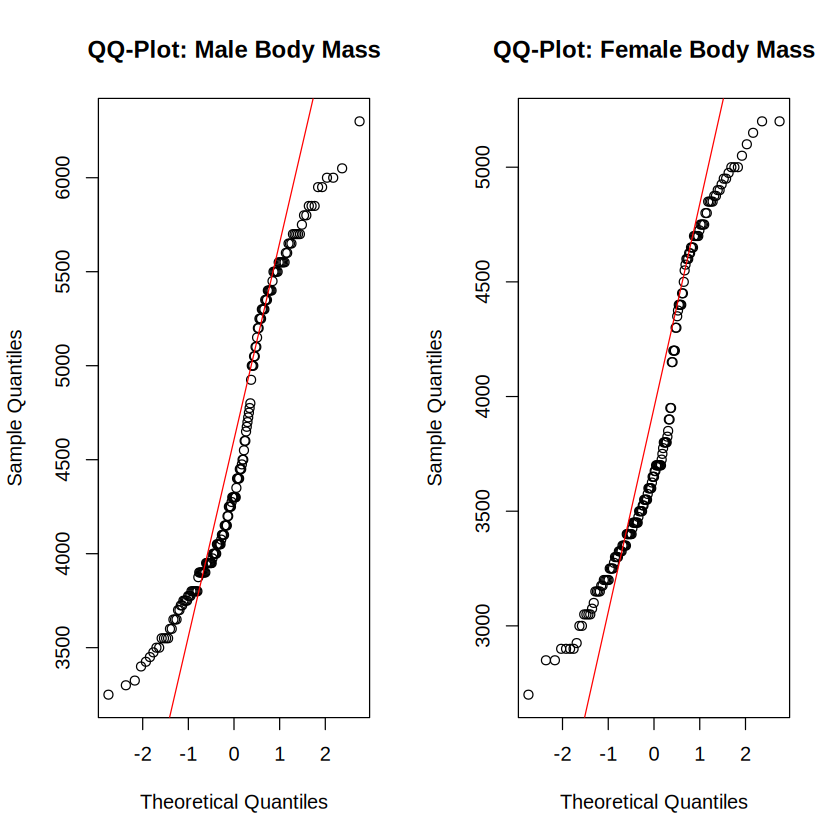

In [9]:
par(mfrow = c(1, 2))
qqnorm(male_mass, main = "QQ-Plot: Male Body Mass");     qqline(male_mass, col = "red")
qqnorm(female_mass, main = "QQ-Plot: Female Body Mass"); qqline(female_mass, col = "red")
par(mfrow = c(1, 1))

In [10]:
t_test_result <- t.test(body_mass_g ~ sex, data = penguins_clean, var.equal = FALSE)
print(t_test_result)

print(t_test_result$conf.int)

cohend_result <- cohen.d(body_mass_g ~ sex, data = penguins_clean)
print(cohend_result)


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 

[1] -840.5783 -526.2453
attr(,"conf.level")
[1] 0.95

Cohen's d

d estimate: -0.9362048 (large)
95 percent confidence interval:
     lower      upper 
-1.1633158 -0.7090938 



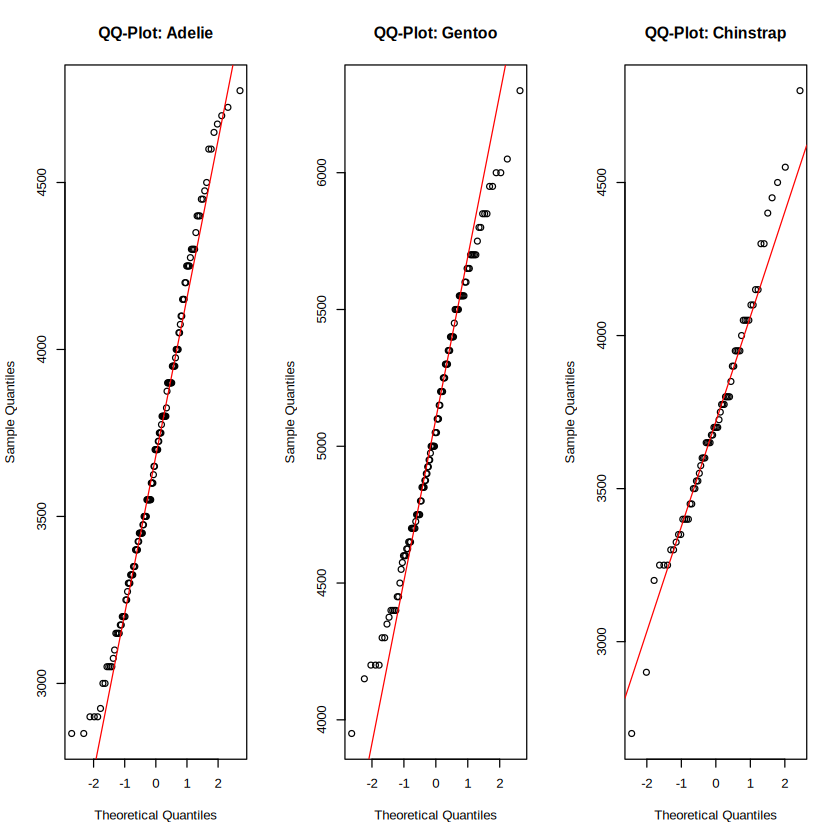

In [11]:
species_list <- unique(penguins_clean$species)

par(mfrow = c(1, 3))
for (sp in species_list) {
  sub_data <- penguins_clean$body_mass_g[penguins_clean$species == sp]
  qqnorm(sub_data, main = paste("QQ-Plot:", sp)); qqline(sub_data, col = "red")
}
par(mfrow = c(1, 1))

In [12]:
for (sp in species_list) {
  sub_data <- penguins_clean$body_mass_g[penguins_clean$species == sp]
  cat("\nShapiro-Wilk test for", as.character(sp), ":\n")
  print(shapiro.test(sub_data))
}

leveneTest(body_mass_g ~ species, data = penguins_clean)


Shapiro-Wilk test for Adelie :

	Shapiro-Wilk normality test

data:  sub_data
W = 0.98116, p-value = 0.04232


Shapiro-Wilk test for Gentoo :

	Shapiro-Wilk normality test

data:  sub_data
W = 0.98606, p-value = 0.2605


Shapiro-Wilk test for Chinstrap :

	Shapiro-Wilk normality test

data:  sub_data
W = 0.98449, p-value = 0.5605



,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000



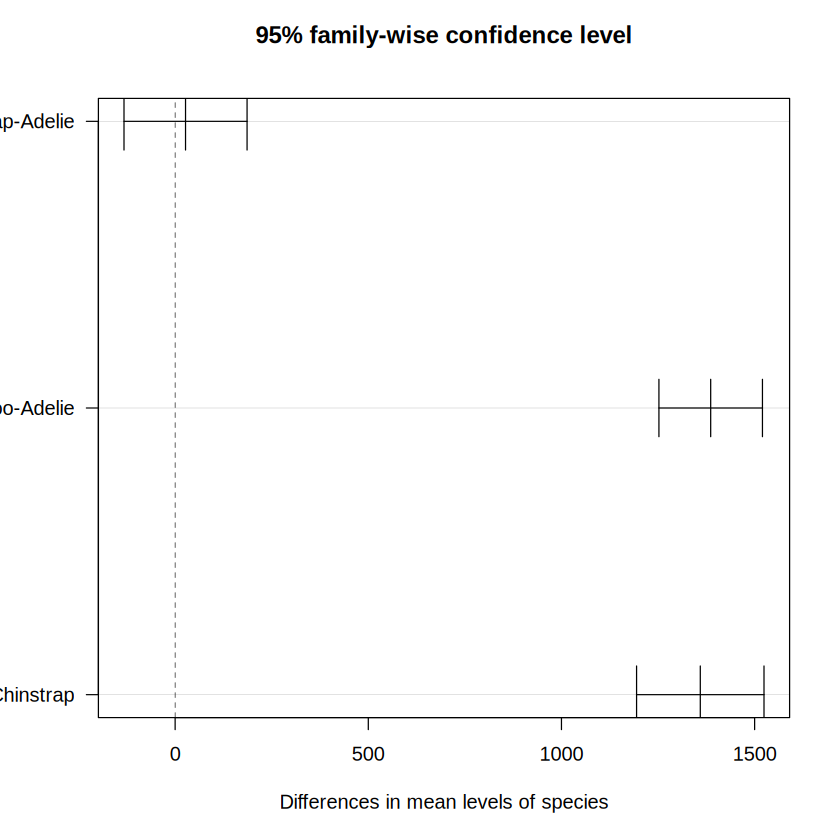

In [13]:
anova_model <- aov(body_mass_g ~ species, data = penguins_clean)
anova_summary <- summary(anova_model)
print(anova_summary)

p_value_anova <- anova_summary[[1]][["Pr(>F)"]][1]
if (p_value_anova < 0.05) {
  tukey_result <- TukeyHSD(anova_model)
  print(tukey_result)
  plot(tukey_result, las = 1)
}

In [14]:
kruskal_result <- kruskal.test(body_mass_g ~ species, data = penguins_clean)
print(kruskal_result)

cat("ANOVA p-value:          ", format.pval(p_value_anova), "\n")
cat("Kruskal-Wallis p-value: ", format.pval(kruskal_result$p.value), "\n")


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16

ANOVA p-value:           < 2.22e-16 
Kruskal-Wallis p-value:  < 2.22e-16 


In [15]:
two_way_model <- aov(body_mass_g ~ species * sex, data = penguins_clean)
print(summary(two_way_model))

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


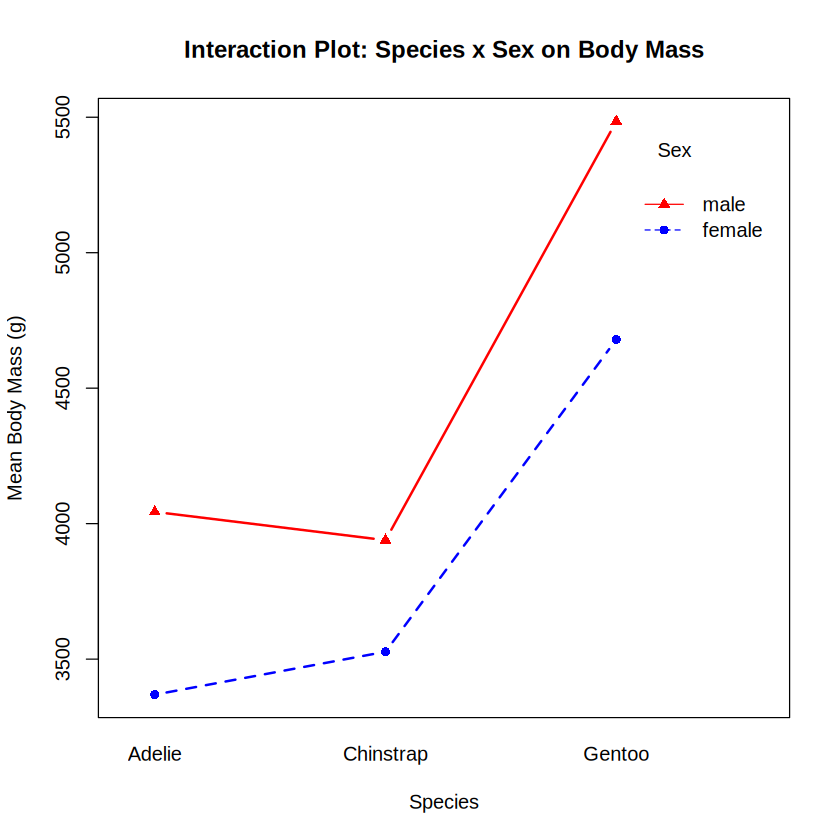

In [16]:
interaction.plot(penguins_clean$species, penguins_clean$sex, penguins_clean$body_mass_g,
                  col = c("blue", "red"), lwd = 2, type = "b", pch = c(16, 17),
                  xlab = "Species", ylab = "Mean Body Mass (g)",
                  trace.label = "Sex", main = "Interaction Plot: Species x Sex on Body Mass")

In [17]:
flipper_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(n = n(), Mean = mean(flipper_length_mm), Median = median(flipper_length_mm),
            SD = sd(flipper_length_mm), Min = min(flipper_length_mm), Max = max(flipper_length_mm),
            Skewness = skewness(flipper_length_mm), Kurtosis = kurtosis(flipper_length_mm))
print(flipper_stats)

for (sp in species_list) {
  sub_data <- penguins_clean$flipper_length_mm[penguins_clean$species == sp]
  print(shapiro.test(sub_data))
}

leveneTest(flipper_length_mm ~ species, data = penguins_clean)

# A tibble: 3 × 9
  species       n  Mean Median    SD   Min   Max Skewness Kurtosis
  <fct>     <int> <dbl>  <dbl> <dbl> <int> <int>    <dbl>    <dbl>
1 Adelie      146  190.    190  6.52   172   210  0.0796      3.33
2 Chinstrap    68  196.    196  7.13   178   212 -0.00926     2.96
3 Gentoo      119  217.    216  6.59   203   231  0.364       2.32

	Shapiro-Wilk normality test

data:  sub_data
W = 0.9934, p-value = 0.7427


	Shapiro-Wilk normality test

data:  sub_data
W = 0.96148, p-value = 0.00176


	Shapiro-Wilk normality test

data:  sub_data
W = 0.98891, p-value = 0.8106



,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.4427865,0.6426253
,330,NA,NA


In [18]:
anova_flipper <- aov(flipper_length_mm ~ species, data = penguins_clean)
anova_flipper_summary <- summary(anova_flipper)
print(anova_flipper_summary)

p_value_flipper <- anova_flipper_summary[[1]][["Pr(>F)"]][1]
if (p_value_flipper < 0.05) {
  print(TukeyHSD(anova_flipper))
}

kruskal.test(flipper_length_mm ~ species, data = penguins_clean)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0




	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


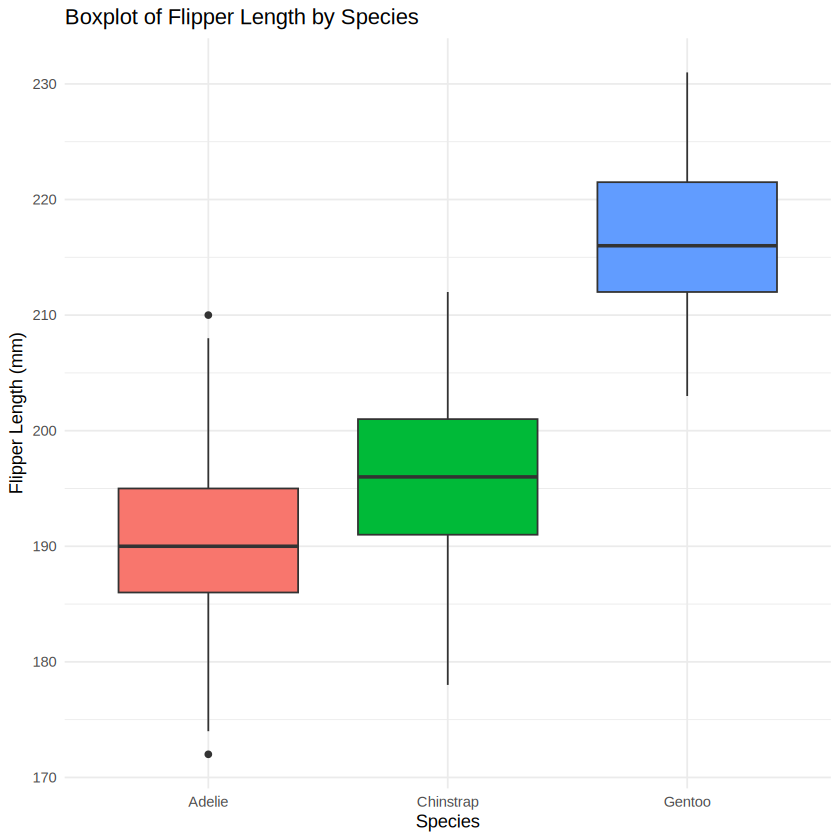

In [19]:
ggplot(penguins_clean, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Flipper Length by Species", x = "Species", y = "Flipper Length (mm)") +
  theme_minimal() + theme(legend.position = "none")

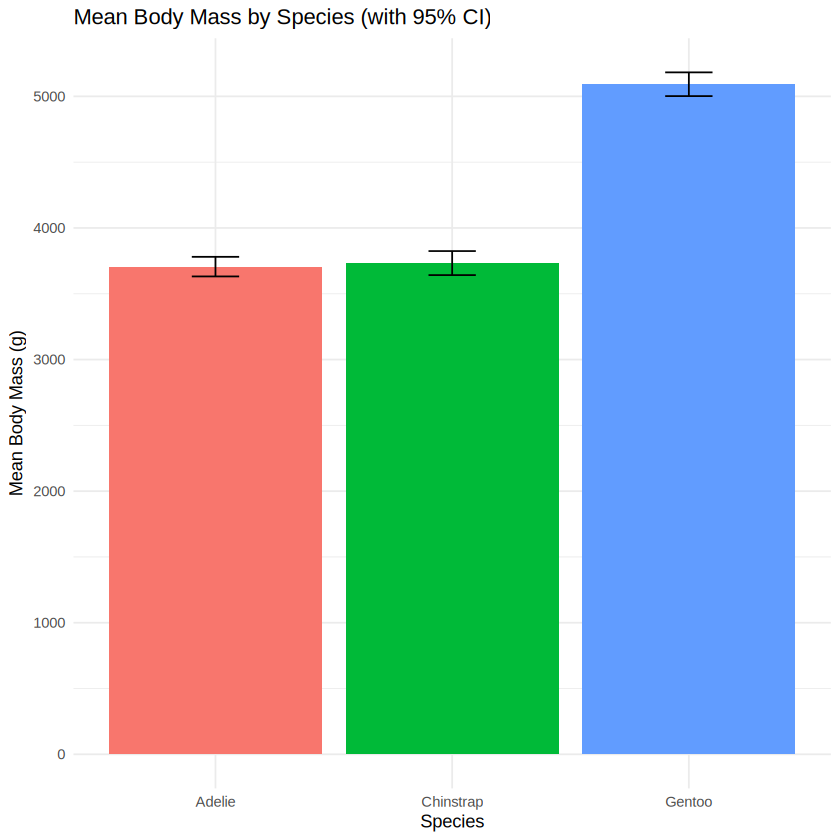

In [20]:
summary_plot_data <- penguins_clean %>%
  group_by(species) %>%
  summarise(mean_mass = mean(body_mass_g), se_mass = sd(body_mass_g) / sqrt(n()))

ggplot(summary_plot_data, aes(x = species, y = mean_mass, fill = species)) +
  geom_col() +
  geom_errorbar(aes(ymin = mean_mass - 1.96 * se_mass, ymax = mean_mass + 1.96 * se_mass), width = 0.2) +
  labs(title = "Mean Body Mass by Species (with 95% CI)", x = "Species", y = "Mean Body Mass (g)") +
  theme_minimal() + theme(legend.position = "none")